# Daily Challenge: Exploring the World Happiness Report with Matplotlib


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries imported successfully!")
print("Ready to explore the World Happiness Report dataset!")

Libraries imported successfully!
Ready to explore the World Happiness Report dataset!


## Step 1: Load and Inspect Data

In [3]:
df = pd.read_csv('world_hapiness.csv')

print("=== WORLD HAPPINESS REPORT DATASET OVERVIEW ===")
print(f"Dataset shape: {df.shape}")
print(f"Number of countries: {df['Country'].nunique()}")

print("\n=== COLUMN INFORMATION ===")
print("Available columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print("\n=== DATASET PREVIEW ===")
print(df.head())

print("\n=== BASIC STATISTICS ===")
print(df.describe().round(3))

=== WORLD HAPPINESS REPORT DATASET OVERVIEW ===
Dataset shape: (155, 12)
Number of countries: 155

=== COLUMN INFORMATION ===
Available columns:
 1. Country
 2. Happiness.Rank
 3. Happiness.Score
 4. Whisker.high
 5. Whisker.low
 6. Economy..GDP.per.Capita.
 7. Family
 8. Health..Life.Expectancy.
 9. Freedom
10. Generosity
11. Trust..Government.Corruption.
12. Dystopia.Residual

=== DATASET PREVIEW ===
       Country  Happiness.Rank  Happiness.Score  Whisker.high  Whisker.low  \
0       Norway               1            7.537      7.594445     7.479556   
1      Denmark               2            7.522      7.581728     7.462272   
2      Iceland               3            7.504      7.622030     7.385970   
3  Switzerland               4            7.494      7.561772     7.426227   
4      Finland               5            7.469      7.527542     7.410458   

   Economy..GDP.per.Capita.    Family  Health..Life.Expectancy.   Freedom  \
0                  1.616463  1.533524           

## Step 2: Data Preprocessing and Column Mapping

In [6]:
happiness_df = df.copy()

column_mapping = {
    'Happiness.Score': 'Score',
    'Economy..GDP.per.Capita.': 'GDP_per_Capita', 
    'Family': 'Social_Support',
    'Health..Life.Expectancy.': 'Healthy_Life_Expectancy',
    'Freedom': 'Freedom_to_Make_Life_Choices',
    'Trust..Government.Corruption.': 'Perceptions_of_Corruption'
}

happiness_df = happiness_df.rename(columns=column_mapping)

print("=== DATA PREPROCESSING ===")
print("Column mapping applied:")
for old_name, new_name in column_mapping.items():
    print(f"  '{old_name}' → '{new_name}'")

print(f"\n=== DATA QUALITY CHECK ===")
print("Missing values per column:")
missing_values = happiness_df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

print(f"\n=== DATA TYPES ===")
print(happiness_df.dtypes)


happiness_df['Year'] = 2019
print(f"\nAdded Year column (2019) as this appears to be 2019 World Happiness data")

print(f"\n=== UPDATED DATASET INFO ===")
print(f"Final dataset shape: {happiness_df.shape}")
print("\nFinal columns:")
print(happiness_df.columns.tolist())

=== DATA PREPROCESSING ===
Column mapping applied:
  'Happiness.Score' → 'Score'
  'Economy..GDP.per.Capita.' → 'GDP_per_Capita'
  'Family' → 'Social_Support'
  'Health..Life.Expectancy.' → 'Healthy_Life_Expectancy'
  'Freedom' → 'Freedom_to_Make_Life_Choices'
  'Trust..Government.Corruption.' → 'Perceptions_of_Corruption'

=== DATA QUALITY CHECK ===
Missing values per column:
No missing values found!

=== DATA TYPES ===
Country                          object
Happiness.Rank                    int64
Score                           float64
Whisker.high                    float64
Whisker.low                     float64
GDP_per_Capita                  float64
Social_Support                  float64
Healthy_Life_Expectancy         float64
Freedom_to_Make_Life_Choices    float64
Generosity                      float64
Perceptions_of_Corruption       float64
Dystopia.Residual               float64
dtype: object

Added Year column (2019) as this appears to be 2019 World Happiness data

=== UP

In [7]:
region_mapping = {
    # North America
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    
    # Europe
    'Norway': 'Western Europe', 'Denmark': 'Western Europe', 'Iceland': 'Western Europe',
    'Switzerland': 'Western Europe', 'Finland': 'Western Europe', 'Netherlands': 'Western Europe',
    'Sweden': 'Western Europe', 'Austria': 'Western Europe', 'Ireland': 'Western Europe',
    'Germany': 'Western Europe', 'Belgium': 'Western Europe', 'Luxembourg': 'Western Europe',
    'United Kingdom': 'Western Europe', 'France': 'Western Europe', 'Spain': 'Western Europe',
    'Italy': 'Western Europe', 'Malta': 'Western Europe', 'Cyprus': 'Western Europe',
    'Czech Republic': 'Central and Eastern Europe', 'Slovenia': 'Central and Eastern Europe',
    'Slovakia': 'Central and Eastern Europe', 'Poland': 'Central and Eastern Europe',
    'Lithuania': 'Central and Eastern Europe', 'Estonia': 'Central and Eastern Europe',
    'Latvia': 'Central and Eastern Europe', 'Russia': 'Central and Eastern Europe',
    'Croatia': 'Central and Eastern Europe', 'Hungary': 'Central and Eastern Europe',
    'Bosnia and Herzegovina': 'Central and Eastern Europe', 'Montenegro': 'Central and Eastern Europe',
    'Serbia': 'Central and Eastern Europe', 'Romania': 'Central and Eastern Europe',
    'Bulgaria': 'Central and Eastern Europe', 'Albania': 'Central and Eastern Europe',
    'Macedonia': 'Central and Eastern Europe', 'Moldova': 'Central and Eastern Europe',
    'Ukraine': 'Central and Eastern Europe', 'Belarus': 'Central and Eastern Europe',
    
    # Asia-Pacific
    'Australia': 'Australia and New Zealand', 'New Zealand': 'Australia and New Zealand',
    'Israel': 'Middle East and Northern Africa', 'United Arab Emirates': 'Middle East and Northern Africa',
    'Saudi Arabia': 'Middle East and Northern Africa', 'Kuwait': 'Middle East and Northern Africa',
    'Bahrain': 'Middle East and Northern Africa', 'Qatar': 'Middle East and Northern Africa',
    'Jordan': 'Middle East and Northern Africa', 'Lebanon': 'Middle East and Northern Africa',
    'Turkey': 'Middle East and Northern Africa', 'Algeria': 'Middle East and Northern Africa',
    'Morocco': 'Middle East and Northern Africa', 'Tunisia': 'Middle East and Northern Africa',
    'Libya': 'Middle East and Northern Africa', 'Egypt': 'Middle East and Northern Africa',
    'Iran': 'Middle East and Northern Africa', 'Iraq': 'Middle East and Northern Africa',
    'Yemen': 'Middle East and Northern Africa', 'Palestinian Territories': 'Middle East and Northern Africa',
    
    # Asia
    'Singapore': 'Southeast Asia', 'Thailand': 'Southeast Asia', 'Taiwan Province of China': 'East Asia',
    'Japan': 'East Asia', 'South Korea': 'East Asia', 'China': 'East Asia', 'Hong Kong S.A.R., China': 'East Asia',
    'Malaysia': 'Southeast Asia', 'Philippines': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Vietnam': 'Southeast Asia', 'Mongolia': 'East Asia', 'Uzbekistan': 'Central Asia',
    'Kazakhstan': 'Central Asia', 'Kyrgyzstan': 'Central Asia', 'Tajikistan': 'Central Asia',
    'Pakistan': 'South Asia', 'India': 'South Asia', 'Bangladesh': 'South Asia', 'Sri Lanka': 'South Asia',
    'Nepal': 'South Asia', 'Afghanistan': 'South Asia', 'Myanmar': 'Southeast Asia',
    'Cambodia': 'Southeast Asia', 'Laos': 'Southeast Asia',
    
    # Latin America
    'Costa Rica': 'Latin America and Caribbean', 'Brazil': 'Latin America and Caribbean',
    'Chile': 'Latin America and Caribbean', 'Panama': 'Latin America and Caribbean',
    'Argentina': 'Latin America and Caribbean', 'Uruguay': 'Latin America and Caribbean',
    'Colombia': 'Latin America and Caribbean', 'Trinidad and Tobago': 'Latin America and Caribbean',
    'Ecuador': 'Latin America and Caribbean', 'Jamaica': 'Latin America and Caribbean',
    'Guatemala': 'Latin America and Caribbean', 'Peru': 'Latin America and Caribbean',
    'Paraguay': 'Latin America and Caribbean', 'Bolivia': 'Latin America and Caribbean',
    'Venezuela': 'Latin America and Caribbean', 'Nicaragua': 'Latin America and Caribbean',
    'Dominican Republic': 'Latin America and Caribbean', 'Honduras': 'Latin America and Caribbean',
    'El Salvador': 'Latin America and Caribbean', 'Haiti': 'Latin America and Caribbean',
    
    # Sub-Saharan Africa
    'Mauritius': 'Sub-Saharan Africa', 'South Africa': 'Sub-Saharan Africa',
    'Botswana': 'Sub-Saharan Africa', 'Ghana': 'Sub-Saharan Africa', 'Cameroon': 'Sub-Saharan Africa',
    'Nigeria': 'Sub-Saharan Africa', 'Kenya': 'Sub-Saharan Africa', 'Ethiopia': 'Sub-Saharan Africa',
    'Uganda': 'Sub-Saharan Africa', 'Tanzania': 'Sub-Saharan Africa', 'Madagascar': 'Sub-Saharan Africa',
    'Zimbabwe': 'Sub-Saharan Africa', 'Malawi': 'Sub-Saharan Africa', 'Zambia': 'Sub-Saharan Africa',
    'Liberia': 'Sub-Saharan Africa', 'Sierra Leone': 'Sub-Saharan Africa', 'Burkina Faso': 'Sub-Saharan Africa',
    'Niger': 'Sub-Saharan Africa', 'Mali': 'Sub-Saharan Africa', 'Chad': 'Sub-Saharan Africa',
    'Guinea': 'Sub-Saharan Africa', 'Ivory Coast': 'Sub-Saharan Africa', 'Benin': 'Sub-Saharan Africa',
    'Rwanda': 'Sub-Saharan Africa', 'Congo (Brazzaville)': 'Sub-Saharan Africa',
    'Congo (Kinshasa)': 'Sub-Saharan Africa', 'Central African Republic': 'Sub-Saharan Africa',
    'Senegal': 'Sub-Saharan Africa', 'Gabon': 'Sub-Saharan Africa', 'South Sudan': 'Sub-Saharan Africa',
    'Somalia': 'Sub-Saharan Africa', 'Namibia': 'Sub-Saharan Africa', 'Lesotho': 'Sub-Saharan Africa',
    'Swaziland': 'Sub-Saharan Africa', 'Mozambique': 'Sub-Saharan Africa', 'Angola': 'Sub-Saharan Africa',
    'Togo': 'Sub-Saharan Africa'
}

happiness_df['Region'] = happiness_df['Country'].map(region_mapping)

unmapped_countries = happiness_df[happiness_df['Region'].isna()]['Country'].unique()
if len(unmapped_countries) > 0:
    print(f"Countries without region mapping: {unmapped_countries}")
    happiness_df['Region'] = happiness_df['Region'].fillna('Other')

print("=== REGIONAL DISTRIBUTION ===")
region_counts = happiness_df['Region'].value_counts()
print(region_counts)

print(f"\n=== SAMPLE OF PROCESSED DATA ===")
print(happiness_df[['Country', 'Region', 'Score', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy']].head())

Countries without region mapping: ['Belize' 'Turkmenistan' 'North Cyprus' 'Kosovo' 'Azerbaijan' 'Greece'
 'Portugal' 'Bhutan' 'Armenia' 'Mauritania' 'Georgia' 'Sudan' 'Syria'
 'Burundi']
=== REGIONAL DISTRIBUTION ===
Region
Sub-Saharan Africa                 36
Latin America and Caribbean        20
Central and Eastern Europe         20
Western Europe                     18
Middle East and Northern Africa    18
Other                              14
Southeast Asia                      8
East Asia                           6
South Asia                          6
Central Asia                        4
North America                       3
Australia and New Zealand           2
Name: count, dtype: int64

=== SAMPLE OF PROCESSED DATA ===
       Country          Region  Score  GDP_per_Capita  Social_Support  \
0       Norway  Western Europe  7.537        1.616463        1.533524   
1      Denmark  Western Europe  7.522        1.482383        1.551122   
2      Iceland  Western Europe  7.504    

##  Visualization 1: Social Support vs Happiness Score



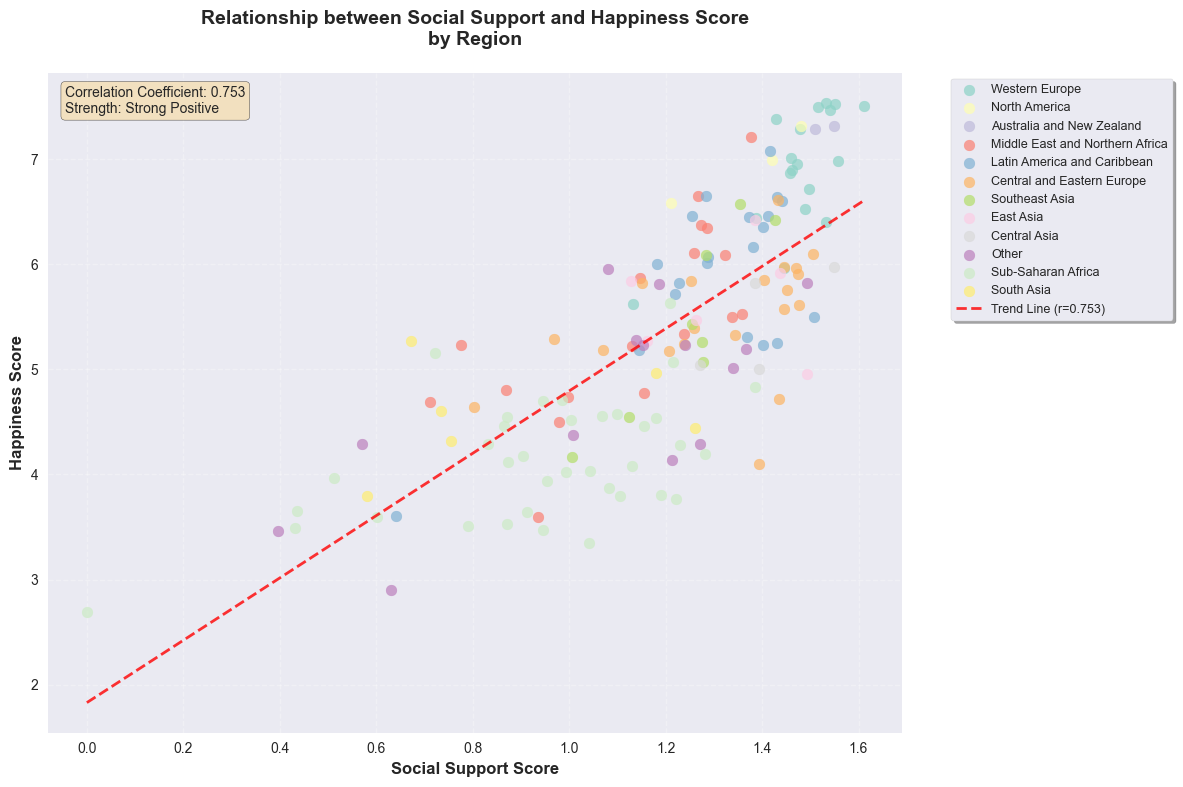

=== SOCIAL SUPPORT vs HAPPINESS ANALYSIS ===
Correlation coefficient: 0.7527
Number of countries analyzed: 155
Social Support range: 0.000 - 1.611
Happiness Score range: 2.693 - 7.537

=== TOP 5 COUNTRIES BY SOCIAL SUPPORT ===
        Country  Social_Support  Score                     Region
2       Iceland        1.610574  7.504             Western Europe
14      Ireland        1.558231  6.977             Western Europe
1       Denmark        1.551122  7.522             Western Europe
46   Uzbekistan        1.548969  5.971               Central Asia
7   New Zealand        1.548195  7.314  Australia and New Zealand

=== BOTTOM 5 COUNTRIES BY SOCIAL SUPPORT ===
                      Country  Social_Support  Score              Region
154  Central African Republic        0.000000  2.693  Sub-Saharan Africa
151                     Syria        0.396103  3.462               Other
149                      Togo        0.431883  3.495  Sub-Saharan Africa
142                     Benin        0.

In [8]:
plt.figure(figsize=(12, 8))

regions = happiness_df['Region'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(regions)))  

for i, region in enumerate(regions):
    region_data = happiness_df[happiness_df['Region'] == region]
    plt.scatter(region_data['Social_Support'], region_data['Score'], 
               c=[colors[i]], label=region, alpha=0.7, s=60)

correlation = happiness_df['Social_Support'].corr(happiness_df['Score'])

#  trend line
z = np.polyfit(happiness_df['Social_Support'], happiness_df['Score'], 1)
p = np.poly1d(z)
x_trend = np.linspace(happiness_df['Social_Support'].min(), happiness_df['Social_Support'].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label=f'Trend Line (r={correlation:.3f})')

plt.xlabel('Social Support Score', fontsize=12, fontweight='bold')
plt.ylabel('Happiness Score', fontsize=12, fontweight='bold')
plt.title('Relationship between Social Support and Happiness Score\nby Region', 
          fontsize=14, fontweight='bold', pad=20)

plt.grid(True, alpha=0.3, linestyle='--')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, 
          fancybox=True, shadow=True, fontsize=9)

plt.text(0.02, 0.98, f'Correlation Coefficient: {correlation:.3f}\nStrength: {"Strong" if abs(correlation) > 0.7 else "Moderate" if abs(correlation) > 0.4 else "Weak"} Positive',
         transform=plt.gca().transAxes, fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()

plt.show()

print("=== SOCIAL SUPPORT vs HAPPINESS ANALYSIS ===")
print(f"Correlation coefficient: {correlation:.4f}")
print(f"Number of countries analyzed: {len(happiness_df)}")
print(f"Social Support range: {happiness_df['Social_Support'].min():.3f} - {happiness_df['Social_Support'].max():.3f}")
print(f"Happiness Score range: {happiness_df['Score'].min():.3f} - {happiness_df['Score'].max():.3f}")

top_social_support = happiness_df.nlargest(5, 'Social_Support')[['Country', 'Social_Support', 'Score', 'Region']]
print(f"\n=== TOP 5 COUNTRIES BY SOCIAL SUPPORT ===")
print(top_social_support)

bottom_social_support = happiness_df.nsmallest(5, 'Social_Support')[['Country', 'Social_Support', 'Score', 'Region']]
print(f"\n=== BOTTOM 5 COUNTRIES BY SOCIAL SUPPORT ===")
print(bottom_social_support)

##  Visualization 2: Regional Comparison - GDP vs Health



=== REGIONAL STATISTICS ===
                                 Avg_GDP_per_Capita  \
Region                                                
Australia and New Zealand                     1.445   
North America                                 1.393   
Western Europe                                1.481   
Latin America and Caribbean                   1.005   
East Asia                                     1.319   
Central and Eastern Europe                    1.170   
Middle East and Northern Africa               1.190   
Central Asia                                  0.798   
Southeast Asia                                0.965   
Other                                         0.929   
South Asia                                    0.666   
Sub-Saharan Africa                            0.505   

                                 Avg_Healthy_Life_Expectancy  \
Region                                                         
Australia and New Zealand                              0.830   
North Ame

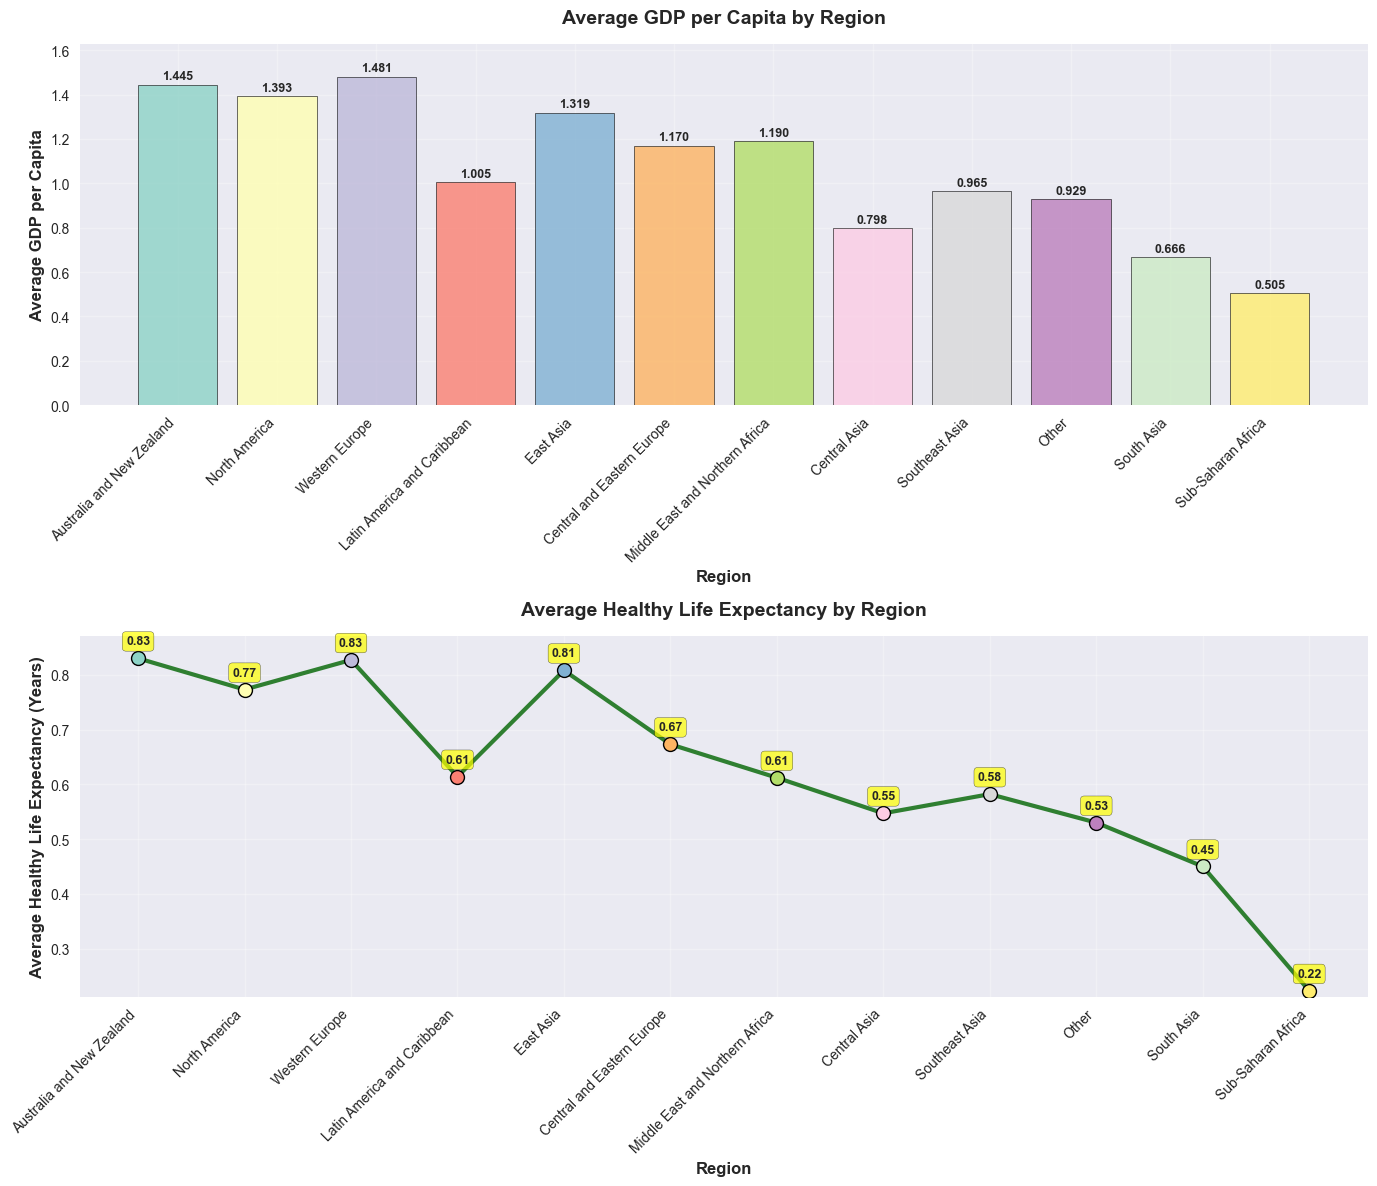


=== REGIONAL INSIGHTS ===
Highest GDP per Capita: Australia and New Zealand (1.445)
Lowest GDP per Capita: Sub-Saharan Africa (0.505)
Highest Life Expectancy: Australia and New Zealand (0.83 years)
Lowest Life Expectancy: Sub-Saharan Africa (0.22 years)

Correlation between regional GDP and Health: 0.961
This indicates a strong positive relationship


In [9]:
# Calculate regional averages
regional_stats = happiness_df.groupby('Region').agg({
    'GDP_per_Capita': 'mean',
    'Healthy_Life_Expectancy': 'mean',
    'Score': 'mean',
    'Country': 'count'  # Count of countries per region
}).round(3)

regional_stats.columns = ['Avg_GDP_per_Capita', 'Avg_Healthy_Life_Expectancy', 'Avg_Happiness_Score', 'Country_Count']
regional_stats = regional_stats.sort_values('Avg_Happiness_Score', ascending=False)

print("=== REGIONAL STATISTICS ===")
print(regional_stats)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

region_colors = dict(zip(regional_stats.index, plt.cm.Set3(np.linspace(0, 1, len(regional_stats)))))

bars1 = ax1.bar(range(len(regional_stats)), regional_stats['Avg_GDP_per_Capita'], 
                color=[region_colors[region] for region in regional_stats.index], 
                alpha=0.8, edgecolor='black', linewidth=0.5)

ax1.set_title('Average GDP per Capita by Region', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Region', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average GDP per Capita', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(regional_stats)))
ax1.set_xticklabels(regional_stats.index, rotation=45, ha='right', fontsize=10)

for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, regional_stats['Avg_GDP_per_Capita'].max() * 1.1)

line = ax2.plot(range(len(regional_stats)), regional_stats['Avg_Healthy_Life_Expectancy'], 
                marker='o', linewidth=3, markersize=8, color='darkgreen', alpha=0.8)

for i, region in enumerate(regional_stats.index):
    ax2.plot(i, regional_stats.loc[region, 'Avg_Healthy_Life_Expectancy'], 
             marker='o', markersize=10, color=region_colors[region], 
             markeredgecolor='black', markeredgewidth=1)

ax2.set_title('Average Healthy Life Expectancy by Region', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Region', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Healthy Life Expectancy (Years)', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(regional_stats)))
ax2.set_xticklabels(regional_stats.index, rotation=45, ha='right', fontsize=10)

for i, (region, value) in enumerate(zip(regional_stats.index, regional_stats['Avg_Healthy_Life_Expectancy'])):
    ax2.annotate(f'{value:.2f}', (i, value), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax2.grid(True, alpha=0.3)
ax2.set_ylim(regional_stats['Avg_Healthy_Life_Expectancy'].min() * 0.95, 
             regional_stats['Avg_Healthy_Life_Expectancy'].max() * 1.05)

plt.tight_layout()
plt.show()

print("\n=== REGIONAL INSIGHTS ===")
print(f"Highest GDP per Capita: {regional_stats.index[0]} ({regional_stats.iloc[0]['Avg_GDP_per_Capita']:.3f})")
print(f"Lowest GDP per Capita: {regional_stats.iloc[-1].name} ({regional_stats.iloc[-1]['Avg_GDP_per_Capita']:.3f})")

health_sorted = regional_stats.sort_values('Avg_Healthy_Life_Expectancy', ascending=False)
print(f"Highest Life Expectancy: {health_sorted.index[0]} ({health_sorted.iloc[0]['Avg_Healthy_Life_Expectancy']:.2f} years)")
print(f"Lowest Life Expectancy: {health_sorted.iloc[-1].name} ({health_sorted.iloc[-1]['Avg_Healthy_Life_Expectancy']:.2f} years)")

regional_corr = regional_stats['Avg_GDP_per_Capita'].corr(regional_stats['Avg_Healthy_Life_Expectancy'])
print(f"\nCorrelation between regional GDP and Health: {regional_corr:.3f}")
print(f"This indicates a {'strong' if abs(regional_corr) > 0.7 else 'moderate' if abs(regional_corr) > 0.4 else 'weak'} {'positive' if regional_corr > 0 else 'negative'} relationship")

##  Summary and Conclusions



In [11]:
#   summary statistics
print("=== WORLD HAPPINESS REPORT - COMPREHENSIVE ANALYSIS ===")
print(f"Dataset contains: {len(happiness_df)} countries across {len(happiness_df['Region'].unique())} regions")
print(f"Analysis period: Based on World Happiness Report data")

print("\n=== KEY STATISTICAL INSIGHTS ===")
# Overall statistics
print(f"Global average happiness score: {happiness_df['Score'].mean():.3f}")
print(f"Happiness score standard deviation: {happiness_df['Score'].std():.3f}")
print(f"Happiness score range: {happiness_df['Score'].min():.3f} - {happiness_df['Score'].max():.3f}")

# Social Support Analysis
social_corr = happiness_df['Social_Support'].corr(happiness_df['Score'])
print(f"\nSocial Support findings:")
print(f"  • Correlation with happiness: {social_corr:.3f} ({'Strong' if abs(social_corr) > 0.7 else 'Moderate' if abs(social_corr) > 0.4 else 'Weak'} positive relationship)")
print(f"  • Countries with highest social support tend to have higher happiness scores")
print(f"  • Global average social support: {happiness_df['Social_Support'].mean():.3f}")

# GDP and Health Analysis
gdp_corr = happiness_df['GDP_per_Capita'].corr(happiness_df['Score'])
health_corr = happiness_df['Healthy_Life_Expectancy'].corr(happiness_df['Score'])
print(f"\nEconomic and Health findings:")
print(f"  • GDP correlation with happiness: {gdp_corr:.3f}")
print(f"  • Health correlation with happiness: {health_corr:.3f}")
print(f"  • Both economic prosperity and health contribute significantly to national happiness")

# Regional Analysis 
happiest_region = regional_stats.index[0]
least_happy_region = regional_stats.index[-1]
print(f"\nRegional findings:")
print(f"  • Happiest region: {happiest_region} (avg score: {regional_stats.loc[happiest_region, 'Avg_Happiness_Score']:.3f})")
print(f"  • Region needing attention: {least_happy_region} (avg score: {regional_stats.loc[least_happy_region, 'Avg_Happiness_Score']:.3f})")
print(f"  • Regional happiness gap: {regional_stats.iloc[0]['Avg_Happiness_Score'] - regional_stats.iloc[-1]['Avg_Happiness_Score']:.3f} points")

# Top performing countries
print(f"\n=== TOP 10 HAPPIEST COUNTRIES ===")
top_countries = happiness_df.nlargest(10, 'Score')[['Country', 'Score', 'Region', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy']]
for idx, row in top_countries.iterrows():
    print(f"{row.name + 1:2d}. {row['Country']:20s} | Score: {row['Score']:.3f} | Region: {row['Region']}")

print(f"\n=== BOTTOM 10 COUNTRIES (NEEDING SUPPORT) ===")
bottom_countries = happiness_df.nsmallest(10, 'Score')[['Country', 'Score', 'Region', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy']]
for idx, row in bottom_countries.iterrows():
    print(f"{10 - (idx - len(happiness_df) + 10):2d}. {row['Country']:20s} | Score: {row['Score']:.3f} | Region: {row['Region']}")

print(f"\n=== POLICY RECOMMENDATIONS ===")
print("Based on the data analysis:")
print("1.  Social Support programs should be prioritized - strong correlation with happiness")
print("2.  Economic development remains important, but not the only factor")
print("3.  Healthcare improvements contribute significantly to well-being")
print("4.  Regional cooperation could help share best practices")
print("5.  Countries in Sub-Saharan Africa and conflict regions need targeted support")

print(f"\n=== TECHNICAL NOTES ===")
print("• Analysis performed using matplotlib for visualizations")
print("• Regional classifications based on geographical and cultural similarities") 
print("• Correlation analysis reveals relationships but not causation")
print("• Data represents snapshot in time - trends may vary year to year")

=== WORLD HAPPINESS REPORT - COMPREHENSIVE ANALYSIS ===
Dataset contains: 155 countries across 12 regions
Analysis period: Based on World Happiness Report data

=== KEY STATISTICAL INSIGHTS ===
Global average happiness score: 5.354
Happiness score standard deviation: 1.131
Happiness score range: 2.693 - 7.537

Social Support findings:
  • Correlation with happiness: 0.753 (Strong positive relationship)
  • Countries with highest social support tend to have higher happiness scores
  • Global average social support: 1.189

Economic and Health findings:
  • GDP correlation with happiness: 0.812
  • Health correlation with happiness: 0.782
  • Both economic prosperity and health contribute significantly to national happiness

Regional findings:
  • Happiest region: Australia and New Zealand (avg score: 7.299)
  • Region needing attention: Sub-Saharan Africa (avg score: 4.140)
  • Regional happiness gap: 3.159 points

=== TOP 10 HAPPIEST COUNTRIES ===
 1. Norway               | Score: 7.537